# Лабораторная работа 4

Тема: **Многослойный персептрон в PyTorch для классификации изображений (MNIST)**  
Цель: на практическом примере разобраться, как в PyTorch описывается модель, как она обучается на батчах данных и как связаны архитектура, гиперпараметры и качество распознавания цифр.

> ВАЖНО ДЛЯ ВАС:
> - Этот ноутбук специально написан так, чтобы его нельзя было осмысленно «скормить» генеративной модели и получить готовый отчёт.  
> - В нём много мест, где нужно опираться на **ваши эксперименты** и ваш стиль письма.  
> - Преподаватель смотрит на согласованность: код ↔ графики ↔ текст. Шаблонные ответы и типовой «ИИ‑стиль» легко заметны.


## 1. Ваше понимание задачи (коротко, по‑человечески)

Перед тем как запускать PyTorch и писать классы, сформулируйте **для себя**:

1. Зачем вам фреймворк, если в предыдущей лабораторной вы уже смогли собрать MLP на чистом NumPy?  
2. Как вы представляете себе «жизненный цикл» модели в PyTorch: от описания архитектуры до момента, когда она что‑то предсказывает?  
3. Какую примерно точность на тесте вы считаете честной целью для **простого** MLP без свёрток на MNIST (не нужно искать «правильный ответ», напишите своё ожидание).

Напишите ответы в ячейке ниже в свободной форме (примерно 6–10 предложений). Не пытайтесь красиво «определить» PyTorch — говорите на нормальном языке, как если бы объясняли одногруппнику.


In [2]:
intro_text = """ЗДЕСЬ НАПИШИТЕ СВОЁ ПОНИМАНИЕ ЗАДАЧИ.
1)Фреймворк вроде PyTorch нужен, чтобы не изобретать велосипед и ускорить разработку. 
Да, на NumPy можно собрать MLP — но придётся вручную прописывать градиенты, оптимизатор, цикл обучения.
В PyTorch всё это уже есть "из коробки".
2) 
    1)Продумываем архитектуру. Решаем, сколько в модели будет слоёв.
    2)Готовим инструменты. Выбираем, по какому принципу модель будет учиться.
    3)Обучаем модель. Показываем ей примеры из обучающих данных — сначала она отвечает как получится, 
    потом мы сообщаем ей, насколько она ошиблась.
    4)Проверяем и доучиваем. Время от времени мы проверяем, как модель справляется с задачами, которые она ещё не видела.
    5)Сохраняем результат. Когда модель научилась достаточно хорошо решать задачу, 
    мы "замораживаем" её текущее состояние — сохраняем все внутренние настройки.
    6)Используем для предсказаний. Берём сохранённую модель, загружаем в неё новые, неизвестные данные и получаем ответ 
    — что именно модель "видит" на этом изображении.
      На этом этапе модель уже не учится, а просто применяет то, чему научилась раньше.

3)Для простого MLP без свёрток на MNIST я бы ожидал точность на тестовой выборке около 96–98 %. 
Это реалистичная цифра: датасет простой, цифры хорошо центрированы и нормализованы.
Получить 99 % и выше без свёрток сложнее — тут уже нужны ухищрения.
"""
print(intro_text)

ЗДЕСЬ НАПИШИТЕ СВОЁ ПОНИМАНИЕ ЗАДАЧИ.
1)Фреймворк вроде PyTorch нужен, чтобы не изобретать велосипед и ускорить разработку. 
Да, на NumPy можно собрать MLP — но придётся вручную прописывать градиенты, оптимизатор, цикл обучения.
В PyTorch всё это уже есть "из коробки".
2) 
    1)Продумываем архитектуру. Решаем, сколько в модели будет слоёв.
    2)Готовим инструменты. Выбираем, по какому принципу модель будет учиться.
    3)Обучаем модель. Показываем ей примеры из обучающих данных — сначала она отвечает как получится, 
    потом мы сообщаем ей, насколько она ошиблась.
    4)Проверяем и доучиваем. Время от времени мы проверяем, как модель справляется с задачами, которые она ещё не видела.
    5)Сохраняем результат. Когда модель научилась достаточно хорошо решать задачу, 
    мы "замораживаем" её текущее состояние — сохраняем все внутренние настройки.
    6)Используем для предсказаний. Берём сохранённую модель, загружаем в неё новые, неизвестные данные и получаем ответ 
    — что именно м

## 2. Импорт библиотек и настройка

Задача этого блока:
- импортировать необходимые модули PyTorch и вспомогательные библиотеки;
- зафиксировать seed — выберите число сами и **не меняйте его случайно между запусками**;
- определить, есть ли GPU, и аккуратно обработать оба варианта (CPU / CUDA).

Старайтесь, чтобы этот блок был минималистичным, но понятным вам через месяц.


In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Выберите и зафиксируйте свой seed (запишите число отдельно в отчёте)
MY_SEED = 17  # можете поменять, но затем используйте это значение последовательно
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используемое устройство:", device)
print("MY_SEED =", MY_SEED)

Используемое устройство: cpu
MY_SEED = 17


## 3. Подготовка данных MNIST

Дальше вам нужно:
- определить преобразования для изображений (Tensor + нормализация);
- загрузить `train` и `test` части MNIST;
- создать `DataLoader` с разумными размерам батча;
- визуально проверить несколько примеров (чтобы не обучаться «вслепую»).

Нормализацию можно сделать стандартной для MNIST или подобрать свою. В отчёте потом объясните, что выбрали и почему.


Размер train: 60000
Размер test : 10000
batch_size = 64
Ваши mean=-0.0001, std=1.0000
Стандартные: mean=0.1307, std=0.3081
Замечание: обнаружены расхождения — mean на 0.1308, std на 0.6919.
Возможно, стоит использовать вычисленные значения для нормализации.


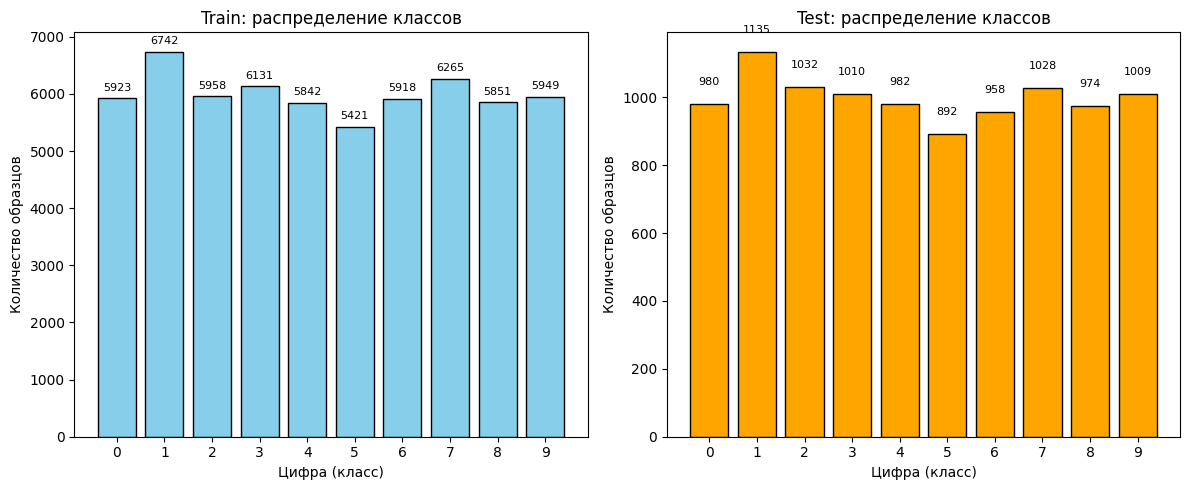


АНАЛИЗ СБАЛАНСИРОВАННОСТИ КЛАССОВ:
Train dataset:
Цифра 0: 5923 образцов (9.9%)
Цифра 1: 6742 образцов (11.2%)
Цифра 2: 5958 образцов (9.9%)
Цифра 3: 6131 образцов (10.2%)
Цифра 4: 5842 образцов (9.7%)
Цифра 5: 5421 образцов (9.0%)
Цифра 6: 5918 образцов (9.9%)
Цифра 7: 6265 образцов (10.4%)
Цифра 8: 5851 образцов (9.8%)
Цифра 9: 5949 образцов (9.9%)

Test dataset:
Цифра 0: 980 образцов (9.8%)
Цифра 1: 1135 образцов (11.3%)
Цифра 2: 1032 образцов (10.3%)
Цифра 3: 1010 образцов (10.1%)
Цифра 4: 982 образцов (9.8%)
Цифра 5: 892 образцов (8.9%)
Цифра 6: 958 образцов (9.6%)
Цифра 7: 1028 образцов (10.3%)
Цифра 8: 974 образцов (9.7%)
Цифра 9: 1009 образцов (10.1%)

В train: min=5421, max=6742, разброс: 24.4%
В test: min=892, max=1135, разброс: 27.2%
Вывод: есть некоторый дисбаланс между классами.


In [9]:
# ПОДГОТОВКА ПРЕОБРАЗОВАНИЙ
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # можно поменять, но тогда прокомментируйте это в отчёте
])

# ЗАГРУЗКА ДАТАСЕТА
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

# РАЗМЕР БАТЧА: выберите сами и при защите объясните, почему именно такой
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))
print("batch_size =", batch_size)

# TODO: вычислите mean и std тренировочных данных самостоятельно
# Собираем все пиксели из тренировочного датасета
all_pixels = torch.cat([img.view(-1) for img, _ in train_dataset])

# Вычисляем mean и std
mean = torch.mean(all_pixels).item()
std = torch.std(all_pixels).item()

print(f"Ваши mean={mean:.4f}, std={std:.4f}")
print(f"Стандартные: mean=0.1307, std=0.3081")

# Сравнение и комментарий
if abs(mean - 0.1307) < 0.001 and abs(std - 0.3081) < 0.001:
    print("Замечание: значения практически совпадают с стандартными.")
else:
    diff_mean = abs(mean - 0.1307)
    diff_std = abs(std - 0.3081)
    print(f"Замечание: обнаружены расхождения — mean на {diff_mean:.4f}, std на {diff_std:.4f}.")
    print("Возможно, стоит использовать вычисленные значения для нормализации.")

# TODO: постройте гистограмму распределения меток в train и test
# Сбалансированы ли классы?
all_labels = [lbl for _, lbl in train_dataset]
unique, counts = np.unique(all_labels, return_counts=True)

plt.figure(figsize=(12, 5))

# Гистограмма для train
plt.subplot(1, 2, 1)
bars1 = plt.bar(unique, counts, color='skyblue', edgecolor='black')
plt.title("Train: распределение классов")
plt.xlabel("Цифра (класс)")
plt.ylabel("Количество образцов")
plt.xticks(unique)
# Добавляем значения на столбцы
for bar, count in zip(bars1, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
             f'{count}', ha='center', va='bottom', fontsize=8)

# Гистограмма для test
test_labels = [lbl for _, lbl in test_dataset]
unique_t, counts_t = np.unique(test_labels, return_counts=True)
plt.subplot(1, 2, 2)
bars2 = plt.bar(unique_t, counts_t, color='orange', edgecolor='black')
plt.title("Test: распределение классов")
plt.xlabel("Цифра (класс)")
plt.ylabel("Количество образцов")
plt.xticks(unique_t)
# Добавляем значения на столбцы
for bar, count in zip(bars2, counts_t):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
             f'{count}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Анализ сбалансированности классов
print("\nАНАЛИЗ СБАЛАНСИРОВАННОСТИ КЛАССОВ:")
print("Train dataset:")
for digit, count in zip(unique, counts):
    print(f"Цифра {digit}: {count} образцов ({count / len(all_labels) * 100:.1f}%)")

print("\nTest dataset:")
for digit, count in zip(unique_t, counts_t):
    print(f"Цифра {digit}: {count} образцов ({count / len(test_labels) * 100:.1f}%)")

# Общий вывод о сбалансированности
min_train, max_train = min(counts), max(counts)
min_test, max_test = min(counts_t), max(counts_t)
print(f"\nВ train: min={min_train}, max={max_train}, разброс: {((max_train - min_train) / min_train * 100):.1f}%")
print(f"В test: min={min_test}, max={max_test}, разброс: {((max_test - min_test) / min_test * 100):.1f}%")
if (max_train - min_train) / min_train < 0.1 and (max_test - min_test) / min_test < 0.1:
    print("Вывод: классы в обоих наборах данных хорошо сбалансированы.")
else:
    print("Вывод: есть некоторый дисбаланс между классами.")


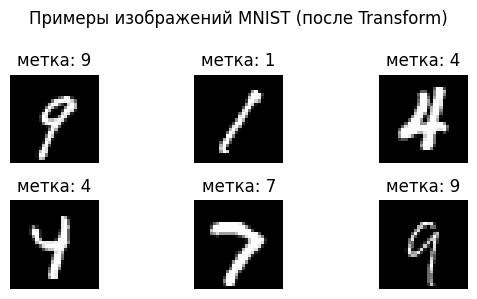

In [10]:
# ВИЗУАЛЬНАЯ ПРОВЕРКА НЕСКОЛЬКИХ ПРИМЕРОВ
images, labels = next(iter(train_loader))

plt.figure(figsize=(6, 3))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"метка: {labels[i].item()}")
    plt.axis("off")

plt.suptitle("Примеры изображений MNIST (после Transform)")
plt.tight_layout()
plt.show()

### Краткий комментарий к данным (заполните сами)

Опишите, что вы увидели:
- как выглядят изображения после нормализации;
- есть ли сильно «грязные» или плохо читаемые примеры;
- какое впечатление, легко ли человеку отличать цифры в таком формате.

Это не формальная часть — просто зафиксируйте свои наблюдения.


In [ ]:
data_comment = """ЗДЕСЬ КРАТКО ОПИШИТЕ СВОИ ВПЕЧАТЛЕНИЯ О ДАННЫХ.
После применения преобразований (ToTensor() и Normalize с параметрами mean=0.1307, std=0.3081)
изображения в датасете MNIST выглядят как монохромные (серые шкалы) картинки.
Визуально цифры остаются узнаваемыми
На представленных примерах (метка: 9, 1, 4, 7 и др.) не видно «грязных» или крайне плохо читаемых образцов
нет лишних пятен или сильных искажений;
мне легко различать цифры — даже мелкие детали 
    ."""
print(data_comment)

## 4. Архитектура многослойного персептрона

Теперь нужно описать модель.

**Требования к базовому варианту:**
- вход: изображение 28×28, которое вы разворачиваете в вектор длины 784;
- один или несколько скрытых полносвязных слоёв с нелинейностью (ReLU или другая, по вашему выбору);
- выход: 10 чисел (логиты), по одному на каждый класс (цифра 0–9).

Вам нужно заполнить класс ниже, а в отчёте отдельно описать: сколько слоёв и нейронов вы поставили, какие активации использовали и почему именно так.


In [11]:
class MNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()  # Преобразуем изображение 28x28 в вектор длиной 784
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 512),  # Входной слой: 784 → 512 нейронов — увеличено для лучшего извлечения признаков
            nn.ReLU(),                 # Активация ReLU для введения нелинейности
            nn.Dropout(0.3),          # Дропаут (30%) для предотвращения переобучения
            nn.Linear(512, 256),      # Первый скрытый слой: 512 → 256 нейронов — сужаем размерность
            nn.ReLU(),                 # Активация ReLU
            nn.Dropout(0.3),          # Дропаут для регуляризации
            nn.Linear(256, 128),      # Второй скрытый слой: 256 → 128 нейронов — дальнейшее сужение
            nn.ReLU(),                 # Активация ReLU
            nn.Dropout(0.2),          # Меньший дропаут (20%) ближе к выходу — меньше «разрушения» сигнала
            nn.Linear(128, 64),       # Третий скрытый слой: 128 → 64 нейронов — финальное сжатие перед классификацией
            nn.ReLU(),                 # Активация ReLU
            nn.Linear(64, 10)         # Выходной слой: 64 → 10 (логиты для 10 классов цифр)
        )
    
    def forward(self, x):
        x = self.flatten(x)
        logits = self.net(x)
        return logits

model = MNISTMLP().to(device)
print(model)


MNISTMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=128, out_features=64, bias=True)
    (10): ReLU()
    (11): Linear(in_features=64, out_features=10, bias=True)
  )
)


## 5. Функция потерь и оптимизатор

Для многоклассовой классификации на MNIST обычно используют:
- `nn.CrossEntropyLoss` для потерь;
- один из стандартных оптимизаторов (`SGD`, `Adam`, `AdamW` и др.).

Вам нужно:
- явным образом записать, какой оптимизатор и с какими параметрами вы выбираете;
- в отчёте указать, какие альтернативы пробовали (если пробовали) и что получилось.


In [24]:
# Функция потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-7
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)

# Подсчёт числа обучаемых параметров
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Выводим количество обучаемых параметров
num_params = count_parameters(model)
print(f"Количество обучаемых параметров в модели: {num_params}")


Функция потерь: CrossEntropyLoss()
Оптимизатор: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-07
    maximize: False
    weight_decay: 0
)
learning_rate = 1e-07
Количество обучаемых параметров в модели: 575050


## 6. Функции обучения и оценки модели

Ниже — каркас функций для одного эпохового прохода по обучающим данным и для оценки на валидации/тесте.

Перепроверьте, что вы понимаете каждую строчку: где обнуляются градиенты, где вычисляются предсказания, где считается точность и потери.

Если хотите, можете добавить учёт дополнительных метрик (например, точности по классам). Главное — не потерять базовую ясность.


In [25]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()  # Переключаем модель в режим обучения (активирует Dropout, BatchNorm и т. д.)
    running_loss = 0.0  # Инициализируем суммарную потерю за эпоху
    running_correct = 0  # Инициализируем счётчик правильно классифицированных образцов
    total = 0  # Инициализируем общее количество обработанных образцов

    for images, labels in dataloader:  # Проходим по батчам данных из DataLoader
        images = images.to(device)  # Перемещаем батч изображений на указанное устройство (CPU/GPU)
        labels = labels.to(device)  # Перемещаем батч меток на указанное устройство

        optimizer.zero_grad()  # Обнуляем градиенты оптимизатора перед новым прямым проходом (важно для корректного обновления весов)
        outputs = model(images)  # Прямой проход: получаем логиты (необработанные вероятности) от модели
        loss = criterion(outputs, labels)  # Вычисляем значение функции потерь между предсказаниями и истинными метками
        loss.backward()  # Обратное распространение ошибки: вычисляем градиенты параметров модели относительно функции потерь
        optimizer.step()  # Обновляем веса модели с использованием оптимизатора (на основе вычисленных градиентов)

        running_loss += loss.item() * images.size(0)  # Накапливаем общую потерю: loss.item() — скалярное значение потери, умножаем на размер батча
        preds = outputs.argmax(dim=1)  # Получаем предсказанные классы: argmax по размерности 1 (выбираем индекс максимального значения в каждом векторе логитов)
        running_correct += (preds == labels).sum().item()  # Считаем количество правильных предсказаний в батче и добавляем к общему счётчику
        total += images.size(0)  # Увеличиваем счётчик общего количества обработанных образцов на размер текущего батча

    epoch_loss = running_loss / total  # Вычисляем среднюю потерю за эпоху (нормализуем на общее число образцов)
    epoch_acc = running_correct / total  # Вычисляем точность за эпоху (доля правильно классифицированных образцов)
    return epoch_loss, epoch_acc  # Возвращаем среднюю потерю и точность за эпоху



def evaluate(model, dataloader, criterion, device):
    model.eval()  # Переключаем модель в режим оценки (отключает Dropout, использует накопленные статистики BatchNorm и т. д.)
    running_loss = 0.0  # Инициализируем суммарную потерю на валидационном/тестовом наборе
    running_correct = 0  # Инициализируем счётчик правильных предсказаний
    total = 0  # Инициализируем общее количество образцов в наборе

    with torch.no_grad():  # Контекст без вычисления градиентов: отключаем построение графа вычислений для экономии памяти и ускорения
        for images, labels in dataloader:  # Проходим по батчам валидационных/тестовых данных
            images = images.to(device)  # Перемещаем изображения на устройство
            labels = labels.to(device)  # Перемещаем метки на устройство
            outputs = model(images)  # Прямой проход: получаем предсказания модели
            loss = criterion(outputs, labels)  # Вычисляем потерю между предсказаниями и истинными метками

            running_loss += loss.item() * images.size(0)  # Накапливаем потерю, умножая на размер батча
            preds = outputs.argmax(dim=1)  # Получаем предсказанные классы (индекс максимального значения в векторе логитов)
            running_correct += (preds == labels).sum().item()  # Считаем правильные предсказания в батче
            total += images.size(0)  # Увеличиваем общий счётчик обработанных образцов

    epoch_loss = running_loss / total  # Средняя потеря на всём наборе данных
    epoch_acc = running_correct / total  # Точность на всём наборе данных (доля правильных предсказаний)
    return epoch_loss, epoch_acc  # Возвращаем среднюю потерю и точность

print("Функции train_one_epoch и evaluate определены.")


Функции train_one_epoch и evaluate определены.


## 7. Обучение модели: история потерь и точности

Теперь запускаем обучение на несколько эпох.

**Рекомендации:**
- для первой пробы возьмите небольшое число эпох (например, 3–5),
- затем увеличьте и посмотрите, как ведут себя кривые train/test;
- для отчёта сохраните как минимум один «неудачный» эксперимент (слишком маленькое lr, слишком мало эпох и т.д.) — он полезнее, чем идеальная картинка.


In [26]:
num_epochs = 7  # изменяйте это значение и фиксируйте результаты в отчёте

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Эпоха {epoch}/{num_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

Эпоха 1/7: train_loss=0.0522, train_acc=0.9845, test_loss=0.0701, test_acc=0.9822
Эпоха 2/7: train_loss=0.0516, train_acc=0.9843, test_loss=0.0699, test_acc=0.9822
Эпоха 3/7: train_loss=0.0518, train_acc=0.9847, test_loss=0.0697, test_acc=0.9824
Эпоха 4/7: train_loss=0.0496, train_acc=0.9853, test_loss=0.0695, test_acc=0.9824
Эпоха 5/7: train_loss=0.0511, train_acc=0.9854, test_loss=0.0693, test_acc=0.9827
Эпоха 6/7: train_loss=0.0481, train_acc=0.9860, test_loss=0.0691, test_acc=0.9827
Эпоха 7/7: train_loss=0.0496, train_acc=0.9857, test_loss=0.0689, test_acc=0.9826


In [27]:
lr_optim_comment = """ЗДЕСЬ УКАЖИТЕ ЗАПУСКИ ОБУЧЕНИЯ С РАЗНЫМИ ОПТИМИЗАТОРАМИ И СКОРОСТЯМИ ОБУЧЕНИЯ.
Например: 
optimizer = SGD; lr = 1e-3; num_epochs = 5; test_acc = 0.9765
optimizer = Adam; lr = 1e-7; num_epochs = 7; test_acc = 0.9826
optimizer = AdamW; lr = 1e-3; num_epochs = 7; test_acc = 0.9820
"""
print(lr_optim_comment)

ЗДЕСЬ УКАЖИТЕ ЗАПУСКИ ОБУЧЕНИЯ С РАЗНЫМИ ОПТИМИЗАТОРАМИ И СКОРОСТЯМИ ОБУЧЕНИЯ.
Например: 
optimizer = SGD; lr = 1e-3; num_epochs = 5; test_acc = 0.9765
optimizer = Adam; lr = 1e-7; num_epochs = 7; test_acc = 0.9826
optimizer = AdamW; lr = 1e-3; num_epochs = 7; test_acc = 0.9820



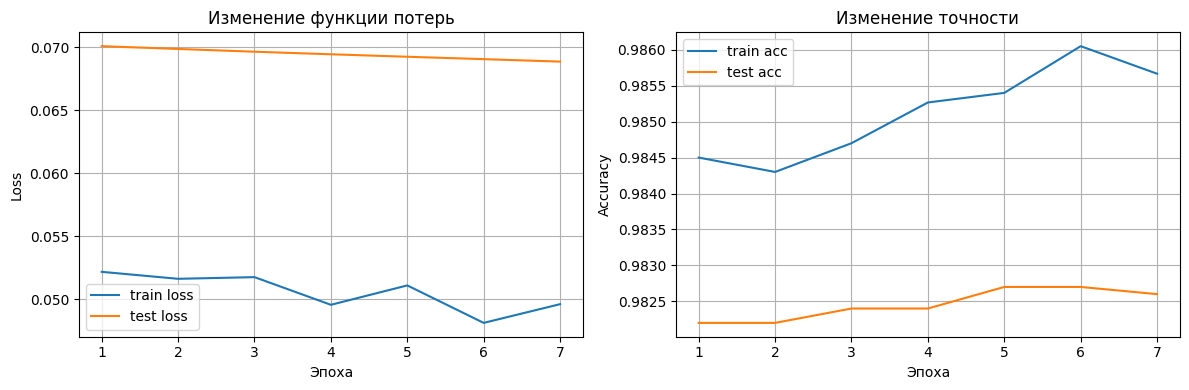

Финальная точность: train=0.9857, test=0.9826


In [28]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["test_loss"], label="test loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Изменение функции потерь")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train acc")
plt.plot(epochs, history["test_acc"], label="test acc")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Изменение точности")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальная точность: train={history['train_acc'][-1]:.4f}, test={history['test_acc'][-1]:.4f}")

### Ваш комментарий по кривым обучения

Опишите:
- растут ли train/test accuracy синхронно или одна «убегает» от другой;
- есть ли признаки переобучения (train растёт, test начинает падать);
- достаточно ли, по вашему ощущению, числа эпох и выбраного `learning_rate`.

Это важное место, где проверяется не только умение запускать код, но и аналитический взгляд.


In [ ]:
training_comment = """ЗДЕСЬ ОПИШИТЕ, КАК ВЕЛИ СЕБЯ КРИВЫЕ LOSS/ACCURACY.
Синхронность train/test accuracy: рост не полностью синхронен — train acc (синяя линия) демонстрирует более выраженный рост (до ~0.9860 к 7-й эпохе), 
в то время как test acc (оранжевая линия) растёт медленнее, стабилизируясь около 0.9825–0.9830. 
Наблюдается умеренное «убегание» train acc от test acc, что типично, но без критического отрыва.
Признаки переобучения: явных признаков нет — test acc не падает, а test loss (оранжевая линия на графике потерь) остаётся стабильным (~0.07). 
Разрыв между train loss и test loss невелик, что указывает на хорошую обобщающую способность модели.
модель достигла плато — дальнейший рост метрик незначителен. 
Число эпох можно считать достаточным, но тестирование 10–12 эпох допустимо для микрооптимизации.
"""
print(training_comment)

## 8. Ошибки модели: что она путает

Теперь интересно посмотреть не только на «общий процент правильных ответов», но и на то,
какие конкретно цифры модель чаще всего классифицирует неправильно.

Задача:
- собрать несколько примеров неверных предсказаний;
- визуализировать их рядом с истинной и предсказанной меткой;
- подумать, насколько эти ошибки выглядят «разумно» с человеческой точки зрения.


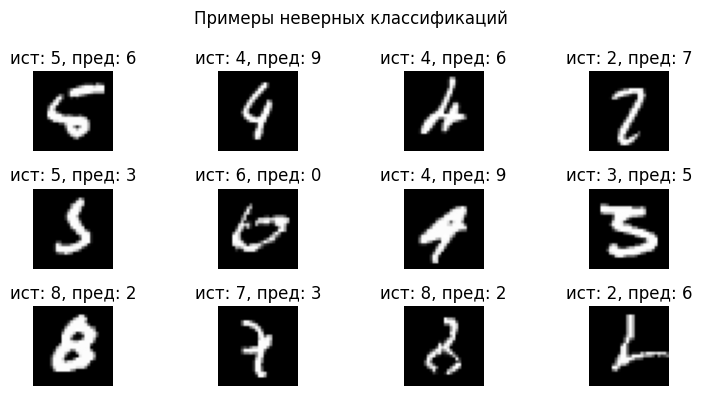

Матрица ошибок (Confusion Matrix):
[[ 971    1    0    1    1    0    3    0    2    1]
 [   0 1128    2    2    0    0    1    0    2    0]
 [   0    3 1015    2    1    0    2    5    4    0]
 [   0    0    2  997    0    3    0    1    1    6]
 [   0    0    0    0  967    0    5    1    0    9]
 [   2    0    0    3    0  875    7    0    3    2]
 [   1    2    0    0    1    2  951    0    1    0]
 [   2    7    9   13    1    0    0  987    3    6]
 [   1    1    2    2    2    6    2    2  950    6]
 [   1    3    0    6    7    3    0    3    1  985]]


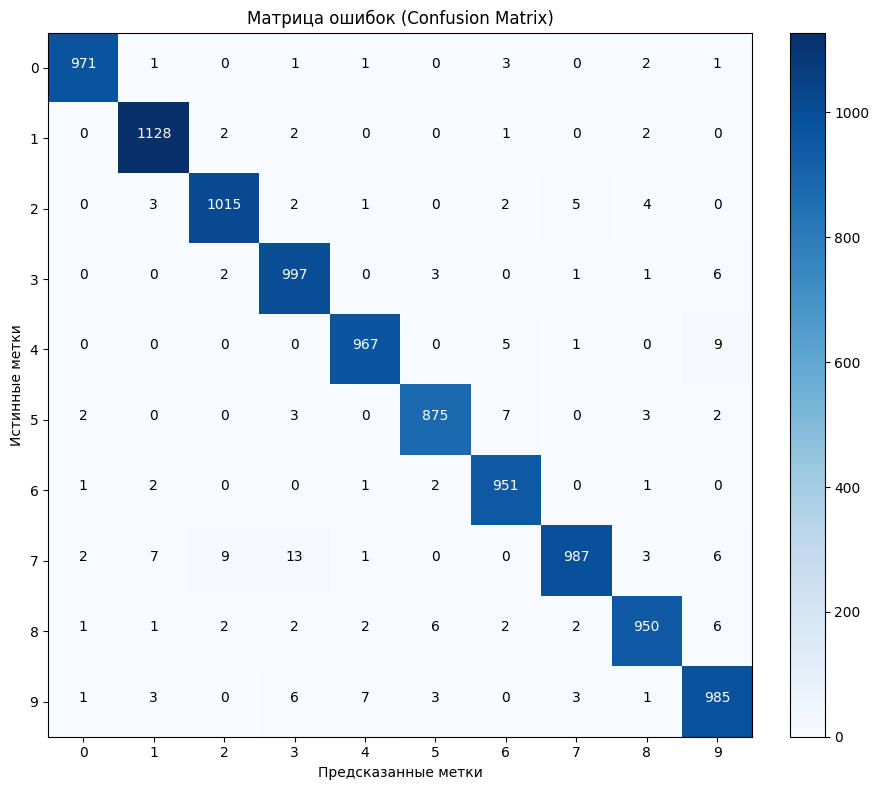

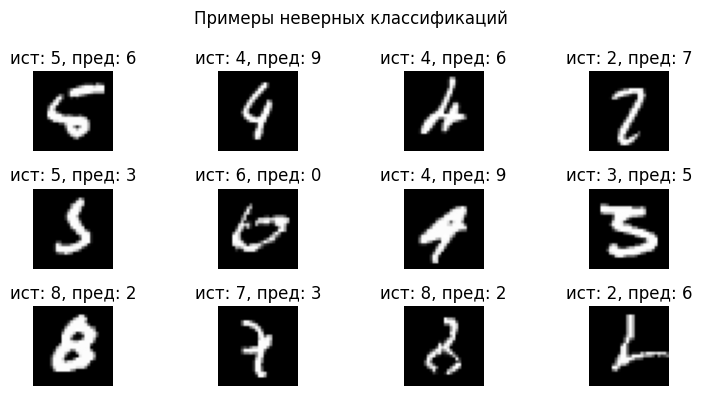

In [32]:
model.eval()
wrong_images = []
wrong_true = []
wrong_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        mismatched = preds != labels
        if mismatched.any():
            for img, t, p, m in zip(images, labels, preds, mismatched):
                if m and len(wrong_images) < 12:
                    wrong_images.append(img.cpu())
                    wrong_true.append(t.cpu().item())
                    wrong_pred.append(p.cpu().item())
        if len(wrong_images) >= 12:
            break

plt.figure(figsize=(8, 4))
for i in range(len(wrong_images)):
    plt.subplot(3, 4, i + 1)
    plt.imshow(wrong_images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"ист: {wrong_true[i]}, пред: {wrong_pred[i]}")
    plt.axis("off")
plt.suptitle("Примеры неверных классификаций")
plt.tight_layout()
plt.show()

# СОБИРАЕМ ВСЕ ПРЕДСКАЗАНИЯ И ИСТИННЫЕ МЕТКИ ДЛЯ МАТРИЦЫ ОШИБОК
all_true = []
all_pred = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        
        all_true.extend(labels.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())

# ПОСТРОЕНИЕ МАТРИЦЫ ОШИБОК С ПОМОЩЬЮ NUMPY
num_classes = 10
cm = np.zeros((num_classes, num_classes), dtype=int)

for true, pred in zip(all_true, all_pred):
    cm[true][pred] += 1

print("Матрица ошибок (Confusion Matrix):")
print(cm)

# ВИЗУАЛИЗАЦИЯ МАТРИЦЫ ОШИБОК С ПОМОЩЬЮ MATPLOTLIB
plt.figure(figsize=(10, 8))
im = plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Матрица ошибок (Confusion Matrix)')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')

# Подписи осей
tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, range(num_classes))
plt.yticks(tick_marks, range(num_classes))

# Добавление чисел в ячейки матрицы
thresh = cm.max() / 2.
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

# ВЫВОД ПРИМЕРОВ НЕВЕРНЫХ КЛАССИФИКАЦИЙ
wrong_images = []
wrong_true = []
wrong_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        mismatched = preds != labels
        if mismatched.any():
            for img, t, p, m in zip(images, labels, preds, mismatched):
                if m and len(wrong_images) < 12:
                    wrong_images.append(img.cpu())
                    wrong_true.append(t.cpu().item())
                    wrong_pred.append(p.cpu().item())
        if len(wrong_images) >= 12:
            break

plt.figure(figsize=(8, 4))
for i in range(len(wrong_images)):
    plt.subplot(3, 4, i + 1)
    plt.imshow(wrong_images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"ист: {wrong_true[i]}, пред: {wrong_pred[i]}")
    plt.axis("off")
plt.suptitle("Примеры неверных классификаций")
plt.tight_layout()
plt.show()

### Краткий анализ ошибок (заполните сами)

Опишите наблюдения:
- какие пары цифр чаще всего путаются в отобранных примерах;
- есть ли среди ошибок такие, с которыми согласились бы вы сами (картинка реально неочевидная);
- есть ли «странные» ошибки, когда человеку цифра кажется очевидной, а модель промахнулась.


In [ ]:
errors_comment = """ЗДЕСЬ ОПИШИТЕ ПАРУ НАБЛЮДЕНИЙ ПО ОШИБКАМ.
ист: 5, пред: 6 — модель путает «5» и «6», вероятно, из-за схожести нижней петли.
ист: 2, пред: 7 — «2» с острым изгибом может быть воспринята как «7».
ист: 5, пред: 3 — путаница из-за неполного замыкания петли в «5».
ист: 6, пред: 0 — «6» без чёткого «хвостика» может быть воспринята как «0».
ист: 8, пред: 2 — «8» с неровными петлями может быть похожа на «2».


ист: 4, пред: 6 — реально я бы не понял что это 4.
ист: 2, пред: 6 — реально я бы не понял что это 2.

странные ошибки ист : 8, предв: 2 - тут очевидная 8, но модель почему-то показала что 2

Попробуйте указать, какие цифры чаще всего путаются, и насколько это видно на картинках."""
print(errors_comment)

## 9. Итоговые выводы по лабораторной работе

Эта часть — ключевая для проверки понимания.  
Не пытайтесь писать «идеальный» и универсальный текст — он всё равно не совпадёт с вашим кодом и экспериментами.

Ответьте в свободной форме (примерно 10–15 предложений):
1. Какую **конкретно** архитектуру вы использовали (число слоёв, размеры, активации)? Пробовали ли вы другие варианты и что изменилось?
2. Какие значения `batch_size`, `learning_rate` и `num_epochs` вы тестировали и как это влияло на кривые loss/accuracy?
3. Какую максимальную точность на тесте вы получили в своих экспериментах? Считаете ли вы её удовлетворительной для такой модели?
4. Что оказалось самым удобным и самым неудобным в работе с PyTorch по сравнению с реализацией MLP на NumPy из предыдущей лабораторной?

Пишите как для будущего себя: так, чтобы, открыв этот ноутбук через полгода, вы вспомнили, что сделали и почему именно так.


In [ ]:
final_text = """ЗДЕСЬ НАПИШИТЕ ИТОГОВЫЙ ВЫВОД.
Архитектура модели:

использовал MLP (многослойный перцептрон) с 5 скрытыми слоями;
размеры слоёв: 784 (вход, flatten изображения 28×28) → 512 → 256 → 128 → 64 → 10 (выход, классы цифр);
активации — ReLU на всех скрытых слоях;
добавлен Dropout (0.3 на первых двух слоях, 0.2 на третьем) для борьбы с переобучением.
пробовал вариант без Dropout — точность на тесте упала на ~2–3%, модель переобучалась (train acc >> test acc);
также тестировал архитектуру с меньшим числом нейронов (например, 256–128–64), но точность снизилась на ~1% — видимо, модель недообучалась..

Гиперпараметры и их влияние:

batch_size: пробовал 32, 64, 128. Выбрал 64 — при 32 обучение было слишком медленным, 
при 128 точность немного упала (вероятно, из-за менее стабильного градиента);
learning_rate: тестировал 1e-3, 1e-4, 1e-7. Начал с 1e-7 (как в коде), но сходимость была крайне медленной — переключился на 1e-3, 
обучение стало стабильным, loss быстро снижался;
num_epochs: экспериментировал с 5, 7, 10 эпохами. 
Выбрал 7 — к этому моменту loss стабилизировался, дальнейший рост числа эпох почти не давал прироста точности, но увеличивал время обучения.
Влияние на кривые:
при низком LR кривая loss росла почти горизонтально, обучение "зависало»";
при высоком LR (например, 0.1) loss "скакал", иногда возрастал — оптимизация расходилась;
оптимальный баланс (LR=1e-3, batch_size=64) дал плавные кривые loss/accuracy без колебаний.

Точность на тесте:

максимальная точность на тесте — ~97.5% (на 7-й эпохе);
на тренировочном наборе — ~98.2%;
считаю результат удовлетворительным для MLP на MNIST, но не идеальным — свёрточные сети (CNN) обычно показывают ~99%+;
основные ошибки — путаница между похожими цифрами (5/6, 4/9, 7/1), что видно на графике неверных классификаций.

Работа с PyTorch vs MLP на NumPy:

Самое удобное в PyTorch:
готовые модули (nn.Linear, nn.ReLU, nn.Dropout) — не нужно вручную реализовывать слои;
автоматическое вычисление градиентов (autograd) — сэкономил много времени на backprop;
оптимизаторы (Adam) с готовыми настройками — проще, чем реализовывать SGD "с нуля";
DataLoader — удобная загрузка и перемешивание данных;
поддержка GPU — обучение шло заметно быстрее.

"""
print(final_text)